<a href="https://colab.research.google.com/github/MostaryKhatun/stress-depression-biomarker-discovery/blob/main/UsingFisharScore_AnalysisCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

stage1_fisher_score_calculation.py

In [27]:
#TODO: Please Maintain the csv file names like this:
# "GSE22356_matrix_Transpose_labeled.csv"


import os
import numpy as np
import pandas as pd
from google.colab import files


# ==========================================================
# Upload Dataset and Save in datasets folder
# ==========================================================

input_directory = "/content/datasets"

os.makedirs(input_directory, exist_ok=True)


print("Upload CSV datasets:")
uploaded = files.upload()


for filename in uploaded.keys():

    os.rename(
        filename,
        os.path.join(input_directory, filename)
    )


print("\nUploaded datasets:")
print(os.listdir(input_directory))



# ==========================================================
# Define Fisher Score Function
# ==========================================================


def fisher_score(X, y):

    classes = np.unique(y)

    num_features = X.shape[1]

    scores = np.zeros(num_features)


    for i in range(num_features):

        feature = X.iloc[:, i]

        mean_total = np.mean(feature)

        numerator = 0

        denominator = 0


        for c in classes:

            class_data = feature[y == c]

            mean_class = np.mean(class_data)


            numerator += (
                len(class_data) *
                (mean_class - mean_total) ** 2
            )


            denominator += (
                len(class_data) *
                np.var(class_data)
            )


        scores[i] = numerator / (denominator + 1e-10)


    return scores



# ==========================================================
# Input and Output Directories
# ==========================================================


output_root_directory = '/content/Processed_Datasets'


score_dir = os.path.join(
    output_root_directory,
    'Score'
)


os.makedirs(
    score_dir,
    exist_ok=True
)



# ==========================================================
# Process Each Dataset
# ==========================================================


for filename in os.listdir(input_directory):


    if filename.endswith('.csv'):


        dataset_path = os.path.join(
            input_directory,
            filename
        )


        dataset_name = os.path.splitext(filename)[0]



        try:

            # Load dataset
            df = pd.read_csv(dataset_path)


        except Exception as e:

            print(
                f"Error reading file '{filename}': {e}. Skipping this file."
            )

            continue



        # Ensure dataset has enough columns

        if df.shape[1] < 2:

            print(
                f"File '{filename}' does not have enough columns. Skipping this file."
            )

            continue



        try:


            # Assuming last column is target

            X = df.iloc[:, :-1]

            y = df.iloc[:, -1]



            # Calculate Fisher Scores

            raw_scores = fisher_score(
                X,
                y
            )



            # Normalize Fisher Scores

            min_score = np.min(raw_scores)

            max_score = np.max(raw_scores)


            normalized_scores = (
                raw_scores - min_score
            ) / (
                max_score - min_score + 1e-10
            )



            # Create DataFrame

            feature_scores = pd.DataFrame({

                'Feature': X.columns,

                'Fisher Score': raw_scores,

                'Normalized Fisher Score': normalized_scores,

            })



            # Save Fisher Score CSV

            feature_scores_output_file = os.path.join(

                score_dir,

                f'{dataset_name}_Fisher_Scores.csv'

            )



            feature_scores.to_csv(

                feature_scores_output_file,

                index=False

            )



            print(
                f"Features and their Fisher Scores for '{dataset_name}' saved to '{feature_scores_output_file}'"
            )



        except Exception as e:


            print(
                f"Error processing file '{filename}': {e}. Skipping this file."
            )



print(
    "All datasets have been processed with Fisher scores."
)

Upload CSV datasets:


Saving GSE98793_matrix_Transpose_labeled.csv to GSE98793_matrix_Transpose_labeled.csv
Saving GSE63878_matrix_Transpose_labeled.csv to GSE63878_matrix_Transpose_labeled.csv

Uploaded datasets:
['.ipynb_checkpoints', 'GSE63878_matrix_Transpose_labeled.csv', 'GSE98793_matrix_Transpose_labeled.csv']
Features and their Fisher Scores for 'GSE63878_matrix_Transpose_labeled' saved to '/content/Processed_Datasets/Score/GSE63878_matrix_Transpose_labeled_Fisher_Scores.csv'
Features and their Fisher Scores for 'GSE98793_matrix_Transpose_labeled' saved to '/content/Processed_Datasets/Score/GSE98793_matrix_Transpose_labeled_Fisher_Scores.csv'
All datasets have been processed with Fisher scores.


stage2_feature_selection_plot_column.py

Plotting completed successfully.


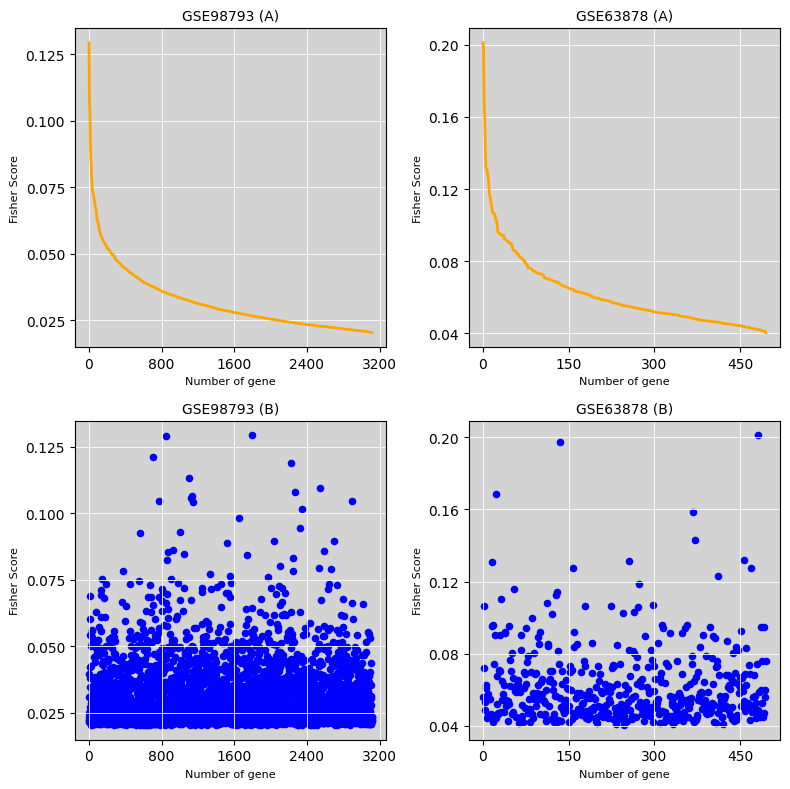

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import os
import numpy as np

def plot_dynamic_subplots_from_folder(folder_path, output_folder):
    # Ensure the output folder exists
    os.makedirs(output_folder, exist_ok=True)

    # Get all CSV files in the folder
    csv_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.csv') and not f.startswith('._')]
    num_files = len(csv_files)
    num_rows = 2  # Two rows: one for line plot, one for scatter plot
    num_cols = num_files  # Each column represents one dataset

    # Define figure size with each dataset in a separate column
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_files * 4, 8))

    # Ensure axs is treated as a 2D array for consistency
    if num_files == 1:
        axs = np.array([[axs[0]], [axs[1]]])
    else:
        axs = np.atleast_2d(axs)

    for i, csv_file in enumerate(csv_files):
        try:
            # Extract the title from the filename
            file_name = os.path.basename(csv_file)
            title_part = file_name.split('_')[0]  # Take the part before the first underscore

            # Load the CSV file
            df = pd.read_csv(csv_file)
            # Visualizing Column Number
            column_number = 1
            df_sorted = df.sort_values(by=df.columns[column_number], ascending=False)

            # Plot the sorted data as a curve plot in the top row
            axs[0, i].set_facecolor('lightgray')
            axs[0, i].plot(range(len(df_sorted)), df_sorted[df_sorted.columns[column_number]], color='orange', linewidth=2)
            axs[0, i].set_title(f'{title_part} (A)', fontsize=10)
            axs[0, i].set_ylabel('Fisher Score', fontsize=8)
            axs[0, i].set_xlabel('Number of gene', fontsize=8)

            # Set custom ticks for x and y axes for less clutter
            axs[0, i].xaxis.set_major_locator(plt.MaxNLocator(5))  # Reduce x-axis ticks
            axs[0, i].yaxis.set_major_locator(plt.MaxNLocator(5))  # Reduce y-axis ticks
            axs[0, i].grid(True, linestyle='-', color='white', linewidth=0.6)

            # Plot the raw data as a scatter plot in the bottom row
            axs[1, i].set_facecolor('lightgray')
            axs[1, i].scatter(range(len(df)), df[df.columns[column_number]], color='blue', s=20)  # Reduced marker size
            axs[1, i].set_title(f'{title_part} (B)', fontsize=10)
            axs[1, i].set_ylabel('Fisher Score', fontsize=8)
            axs[1, i].set_xlabel('Number of gene', fontsize=8)

            # Set custom ticks for x and y axes
            axs[1, i].xaxis.set_major_locator(plt.MaxNLocator(5))  # Reduce x-axis ticks
            axs[1, i].yaxis.set_major_locator(plt.MaxNLocator(5))  # Reduce y-axis ticks
            axs[1, i].grid(True, linestyle='-', color='white', linewidth=0.6)

        except Exception as e:
            print(f"Error processing file '{csv_file}': {e}. Skipping this file.")
            continue

    # Optimize layout spacing
    plt.tight_layout()  # Automatically adjust subplot parameters for a tight layout

    # Save the figure as an image file in the specified output folder
    output_path_base = os.path.join(output_folder, f'combined_plot_fisher_score_column_{column_number}')
    plt.savefig(f'{output_path_base}.png', format='png', dpi=1000)
    plt.savefig(f'{output_path_base}.jpg', format='jpg', dpi=1000)
    plt.savefig(f'{output_path_base}.pdf', format='pdf', dpi=1000)
    plt.savefig(f'{output_path_base}.svg', format='svg', dpi=1000)

    # Show the plot
    # plt.show()

# Example usage
folder_path = './Processed_Datasets/Score'  # Folder containing the CSV files
output_folder = './Processed_Datasets/Plots'  # Folder to save the output plot
plot_dynamic_subplots_from_folder(folder_path, output_folder)
print("Plotting completed successfully.")

stage3_feature_selection.py

In [31]:
import os
import pandas as pd
from google.colab import files

# ==========================================================
# Directories (Google Colab)
# ==========================================================
input_directory = "/content/datasets"
output_root_directory = "/content/Processed_Datasets"

score_dir = os.path.join(output_root_directory, "Score")
report_dir = os.path.join(output_root_directory, "Report")
selection_dir = os.path.join(output_root_directory, "Selection")

# Create output directories
os.makedirs(report_dir, exist_ok=True)
os.makedirs(selection_dir, exist_ok=True)


# ==========================================================
# Check directories
# ==========================================================

if not os.path.exists(score_dir):
    raise FileNotFoundError(
        f"{score_dir} not found. Please run Fisher Score code first."
    )


if not os.path.exists(input_directory):
    raise FileNotFoundError(
        f"{input_directory} not found. Please upload datasets."
    )


# ==========================================================
# Read Fisher Score files
# ==========================================================

datasets = [
    f for f in os.listdir(score_dir)
    if f.endswith("_Fisher_Scores.csv")
    and not f.startswith("._")
]


dataset_names = [
    os.path.splitext(f)[0].replace("_Fisher_Scores", "")
    for f in datasets
]


# ==========================================================
# Display datasets
# ==========================================================

print("Available datasets:\n")

for idx, name in enumerate(dataset_names):
    print(f"{idx+1}. {name}")



# ==========================================================
# Select datasets
# ==========================================================

selected_indices = input(
    "\nEnter dataset indices (Example: 1 3): "
).strip().split()


selected_indices = [
    int(i)-1
    for i in selected_indices
    if i.isdigit()
    and 0 <= int(i)-1 < len(datasets)
]



# ==========================================================
# Process datasets
# ==========================================================

for idx in selected_indices:


    dataset_name = dataset_names[idx]


    score_file = os.path.join(
        score_dir,
        datasets[idx]
    )


    feature_scores = pd.read_csv(score_file)



    # ======================================================
    # Find Original Dataset Automatically
    # ======================================================

    dataset_file = os.path.join(
        input_directory,
        f"{dataset_name}.csv"
    )


    if not os.path.exists(dataset_file):

        raise FileNotFoundError(
            f"""
Original dataset not found:

{dataset_file}

Available files in /content/datasets:

{os.listdir(input_directory)}
"""
        )


    df = pd.read_csv(dataset_file)



    X = df.iloc[:, :-1]

    y = df.iloc[:, -1]



    sorted_feature_scores = feature_scores.sort_values(
        by="Fisher Score",
        ascending=False
    )



    print(f"\nSelect feature selection method for {dataset_name}")


    print("1. Score Threshold")
    print("2. Top N Features")


    choice = int(
        input("\nEnter choice (1 or 2): ")
    )



    report_details = {

        "dataset_name": dataset_name,

        "chosen_option": "",

        "selected_feature_count": 0

    }


    selection_type = ""

    value = 0



    # ======================================================
    # Threshold Selection
    # ======================================================

    if choice == 1:


        threshold = float(
            input("Enter score threshold: ")
        )


        selected_features = sorted_feature_scores[
            sorted_feature_scores["Fisher Score"] >= threshold
        ]["Feature"]



        report_details["chosen_option"] = (
            f"Score threshold >= {threshold}"
        )


        report_details["selected_feature_count"] = (
            len(selected_features)
        )


        selection_type = "Threshold"

        value = threshold



    # ======================================================
    # Top N Selection
    # ======================================================

    elif choice == 2:


        top_n = int(
            input("Enter Top N: ")
        )


        selected_features = (
            sorted_feature_scores
            .head(top_n)["Feature"]
        )


        report_details["chosen_option"] = (
            f"Top {top_n} features"
        )


        report_details["selected_feature_count"] = top_n


        selection_type = "Top"

        value = top_n



    else:

        print("Invalid choice. Skipping...")

        continue



    # ======================================================
    # Save Selected Dataset
    # ======================================================


    X_selected = X[selected_features]


    X_selected_with_target = pd.concat(
        [X_selected, y],
        axis=1
    )



    selection_output_file = os.path.join(
        selection_dir,
        f"{dataset_name}_Selected_{selection_type}_{value}_Features.csv"
    )



    X_selected_with_target.to_csv(
        selection_output_file,
        index=False
    )



    print(
        f"\nSaved:\n{selection_output_file}"
    )



    # ======================================================
    # Save Report
    # ======================================================


    report_file = os.path.join(
        report_dir,
        f"{dataset_name}_Feature_Selection_Report.txt"
    )


    with open(report_file, "w") as f:


        f.write(
            "Fisher Score Feature Selection Report\n"
        )

        f.write(
            "=====================================\n"
        )

        f.write(
            f"Dataset Name: {dataset_name}\n"
        )

        f.write(
            f"Selected Option: {report_details['chosen_option']}\n"
        )

        f.write(
            f"Number of Selected Features: {report_details['selected_feature_count']}\n"
        )

        f.write(
            f"Output CSV File: {selection_output_file}\n"
        )

        f.write(
            f"Fisher Score CSV File: {score_file}\n"
        )



    print(
        f"Report saved:\n{report_file}"
    )



print(
    "\nAll selected datasets have been processed successfully."
)



# ==========================================================
# Download outputs
# ==========================================================

print(
    "\nDownloading generated files..."
)


for folder in [selection_dir, report_dir]:

    for file in os.listdir(folder):

        files.download(
            os.path.join(folder,file)
        )

Available datasets:

1. GSE98793_matrix_Transpose_labeled
2. GSE63878_matrix_Transpose_labeled

Enter dataset indices (Example: 1 3): 1 2

Select feature selection method for GSE98793_matrix_Transpose_labeled
1. Score Threshold
2. Top N Features

Enter choice (1 or 2): 2
Enter Top N: 1000

Saved:
/content/Processed_Datasets/Selection/GSE98793_matrix_Transpose_labeled_Selected_Top_1000_Features.csv
Report saved:
/content/Processed_Datasets/Report/GSE98793_matrix_Transpose_labeled_Feature_Selection_Report.txt

Select feature selection method for GSE63878_matrix_Transpose_labeled
1. Score Threshold
2. Top N Features

Enter choice (1 or 2): 2
Enter Top N: 1000

Saved:
/content/Processed_Datasets/Selection/GSE63878_matrix_Transpose_labeled_Selected_Top_1000_Features.csv
Report saved:
/content/Processed_Datasets/Report/GSE63878_matrix_Transpose_labeled_Feature_Selection_Report.txt

All selected datasets have been processed successfully.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

stage2_feature_selection_plot_row.py

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import os

def plot_dynamic_subplots_from_folder(folder_path, output_folder):
    # Ensure the output folder exists
    os.makedirs(output_folder, exist_ok=True)

    # Get all CSV files in the folder
    csv_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.csv') and not f.startswith('._')]
    num_files = len(csv_files)
    num_plots = num_files * 2  # Each file requires two plots
    num_rows = math.ceil(num_plots / 2)  # Calculate required rows

    # Define a square figure size
    fig, axs = plt.subplots(num_rows, 2, figsize=(8, num_rows * 4))  # Adjusted figure size for compact layout
    axs = axs.flatten()

    for i, csv_file in enumerate(csv_files):
        # Extract the title from the filename
        file_name = os.path.basename(csv_file)
        title_part = file_name.split('_')[0]  # Take the part before the first underscore

        # Load the CSV file
        df = pd.read_csv(csv_file)
        # Column Number
        column_number = 1
        df_sorted = df.sort_values(by=df.columns[column_number], ascending=False)

        # Plot the sorted data as a curve plot
        if i * 2 < len(axs):  # Ensure index is within bounds
            axs[i * 2].set_facecolor('lightgray')
            axs[i * 2].plot(range(len(df_sorted)), df_sorted[df_sorted.columns[column_number]], color='orange', linewidth=2)
            axs[i * 2].set_title(f'{title_part} (A)', fontsize=10)
            axs[i * 2].set_ylabel('Fisher Score', fontsize=8)
            axs[i * 2].set_xlabel('Number of gene', fontsize=8)

            # Set custom ticks for x and y axes for less clutter
            axs[i * 2].xaxis.set_major_locator(plt.MaxNLocator(5))  # Reduce x-axis ticks
            axs[i * 2].yaxis.set_major_locator(plt.MaxNLocator(5))  # Reduce y-axis ticks
            axs[i * 2].grid(True, linestyle='-', color='white', linewidth=0.6)

        # Plot the raw data as a scatter plot
        if i * 2 + 1 < len(axs):  # Ensure index is within bounds
            axs[i * 2 + 1].set_facecolor('lightgray')
            axs[i * 2 + 1].scatter(range(len(df)), df[df.columns[column_number]], color='blue', s=20)  # Reduced marker size
            axs[i * 2 + 1].set_title(f'{title_part} (B)', fontsize=10)
            axs[i * 2 + 1].set_ylabel('Fisher Score', fontsize=8)
            axs[i * 2 + 1].set_xlabel('Number of gene', fontsize=8)

            # Set custom ticks for x and y axes
            axs[i * 2 + 1].xaxis.set_major_locator(plt.MaxNLocator(5))  # Reduce x-axis ticks
            axs[i * 2 + 1].yaxis.set_major_locator(plt.MaxNLocator(5))  # Reduce y-axis ticks
            axs[i * 2 + 1].grid(True, linestyle='-', color='white', linewidth=0.6)

    # Hide any unused subplots
    for j in range(i * 2 + 2, len(axs)):
        axs[j].axis('off')

    # Optimize layout spacing
    plt.tight_layout()  # Automatically adjust subplot parameters for a tight layout

    # Save the figure as an image file in the specified output folder
    output_path_base = os.path.join(output_folder, f'combined_plot_fisher_score_row_{column_number}')
    plt.savefig(f'{output_path_base}.png', format='png', dpi=1000)
    plt.savefig(f'{output_path_base}.jpg', format='jpg', dpi=1000)
    plt.savefig(f'{output_path_base}.pdf', format='pdf', dpi=1000)
    plt.savefig(f'{output_path_base}.svg', format='svg', dpi=1000)

    # Show the plot
    # plt.show()

# Example usage
folder_path = './Processed_Datasets/Score'  # Folder containing the CSV files
output_folder = './Processed_Datasets/Plots'  # Folder to save the output plot
plot_dynamic_subplots_from_folder(folder_path, output_folder)
print("Plotting completed successfully.")